# 02 - Modélisation PD (Probability of Default)
Projet : Credit Risk Scoring (Lending Club)

Objectif de ce notebook :
- Charger les jeux train/test préparés au notebook 01
- Traiter les valeurs extrêmes de `loan_to_income`
- Entraîner et comparer 3 modèles : régression logistique (baseline), Random Forest, XGBoost
- Comparer AUC-ROC, courbes Precision-Recall, calibration
- Choisir le modèle final sur la base de ce tableau, puis déterminer un seuil optimal par coût métier
- Analyse complémentaire : isoler l'apport de la politique d'octroi Lending Club (grade/sub_grade/int_rate)

In [1]:
import sys
sys.path.append("..")

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
from xgboost import XGBClassifier

from src.metrics import (
    compute_auc, compute_roc_curve, compute_brier_score, optimal_threshold_by_cost
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Chargement des jeux train/test

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")

print(f"Train : {train.shape[0]:,} lignes, {train.shape[1]} colonnes".replace(",", " "))
print(f"Test  : {test.shape[0]:,} lignes, {test.shape[1]} colonnes".replace(",", " "))

Train : 1 119 711 lignes  46 colonnes
Test  : 169 321 lignes  46 colonnes


## 2. Traitement de l'outlier `loan_to_income`

Constaté au notebook 01 : `loan_to_income` atteint 40 000 pour certains prêts
(revenu annuel déclaré quasi nul). Ce sont de vraies valeurs du dataset, pas une
erreur de calcul, mais un modèle linéaire (régression logistique) y est très
sensible, contrairement aux modèles d'ensemble.

Winsorisation au 99e percentile **calculée sur le train uniquement**, puis
appliquée au test. Les NaN résiduels (`annual_inc = 0` → division par zéro)
sont imputés par la médiane du train.

In [3]:
cap_value = train["loan_to_income"].quantile(0.99)
print(f"Seuil de winsorisation (99e percentile du train) : {cap_value:.3f}")

train["loan_to_income"] = train["loan_to_income"].clip(upper=cap_value)
test["loan_to_income"] = test["loan_to_income"].clip(upper=cap_value)

median_lti = train["loan_to_income"].median()
n_na_train = train["loan_to_income"].isna().sum()
n_na_test = test["loan_to_income"].isna().sum()
print(f"Valeurs manquantes imputées : {n_na_train} (train), {n_na_test} (test)")

train["loan_to_income"] = train["loan_to_income"].fillna(median_lti)
test["loan_to_income"] = test["loan_to_income"].fillna(median_lti)

print("\nDistribution après winsorisation et imputation (train) :")
print(train["loan_to_income"].describe())

Seuil de winsorisation (99e percentile du train) : 0.486
Valeurs manquantes imputées : 35 (train), 178 (test)

Distribution après winsorisation et imputation (train) :
count    1.119711e+06
mean     2.148078e-01
std      1.112489e-01
min      1.714286e-04
25%      1.269841e-01
50%      2.000000e-01
75%      2.918269e-01
max      4.861111e-01
Name: loan_to_income, dtype: float64


## 3. Préparation des matrices X / y

On retire les colonnes non-features (`default`, `issue_d`, `earliest_cr_line`).
`loan_status` est exclue de l'encodage : c'est la variable source de la cible,
elle ne doit jamais servir de feature (fuite de données directe).

Les noms de colonnes sont nettoyés immédiatement après l'encodage (XGBoost
interdit les caractères `[`, `]`, `<`, qui apparaissent par exemple dans
`emp_length_< 1 year`); appliqué une seule fois ici, avant les 3 modèles,
pour garantir des jeux de features strictement identiques entre eux.

In [4]:
drop_cols = ["default", "issue_d", "earliest_cr_line"]

cat_cols_remaining = train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols_remaining = [c for c in cat_cols_remaining if c != "loan_status"]
print("Colonnes catégorielles à encoder :", cat_cols_remaining)

train_enc = pd.get_dummies(
    train.drop(columns=["loan_status"]), columns=cat_cols_remaining, drop_first=True
)
test_enc = pd.get_dummies(
    test.drop(columns=["loan_status"]), columns=cat_cols_remaining, drop_first=True
)

train_enc, test_enc = train_enc.align(test_enc, join="left", axis=1, fill_value=0)

X_train = train_enc.drop(columns=drop_cols)
y_train = train_enc["default"]
X_test = test_enc.drop(columns=drop_cols)
y_test = test_enc["default"]

def clean_feature_names(df):
    df = df.copy()
    df.columns = [re.sub(r"[\[\]<]", "_", str(col)) for col in df.columns]
    return df

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Colonnes catégorielles à encoder : ['term', 'grade', 'sub_grade', 'emp_length']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8456\3653928995.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_remaining = train.select_dtypes(include=["object", "category"]).columns.tolist()



X_train : (1119711, 90)
X_test  : (169321, 90)


In [5]:
print("NaN restants dans X_train :", X_train.isna().sum().sum())
print("NaN restants dans X_test  :", X_test.isna().sum().sum())

NaN restants dans X_train : 0
NaN restants dans X_test  : 0


## 4. Entraînement des 3 modèles

Baseline interprétable (régression logistique), puis deux familles de modèles
d'ensemble : bagging (Random Forest, arbres indépendants) et boosting (XGBoost,
arbres séquentiels qui corrigent les erreurs précédentes).

### 4.1 Régression logistique (baseline)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float32"))
X_test_scaled = scaler.transform(X_test.astype("float32"))

logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

proba_logreg_test = logreg.predict_proba(X_test_scaled)[:, 1]
auc_logreg = compute_auc(y_test, proba_logreg_test)
print(f"AUC-ROC régression logistique (test) : {auc_logreg:.4f}")

AUC-ROC régression logistique (test) : 0.7042


**Interprétation des coefficients** : les valeurs les plus élevées en valeur
absolue indiquent les variables qui pèsent le plus sur la probabilité de défaut
(en écart-type, puisque les variables sont standardisées).

In [7]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print("Top 15 variables par importance du coefficient :")
coef_df.head(15)

Top 15 variables par importance du coefficient :


,feature,coefficient
17,grade_ordinal,0.464557
38,term_ 60 months,0.289338
40,grade_C,0.224002
39,grade_B,0.201816
3,installment,0.172552
41,grade_D,0.160109
48,sub_grade_A5,0.159979
5,dti,0.154146
8,open_acc,0.137286
16,loan_to_income,0.134477


### 4.2 Random Forest (bagging)

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

proba_rf_test = rf.predict_proba(X_test)[:, 1]
auc_rf = compute_auc(y_test, proba_rf_test)
print(f"AUC-ROC Random Forest (test) : {auc_rf:.4f}")

AUC-ROC Random Forest (test) : 0.7003


### 4.3 XGBoost (boosting)

In [9]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

proba_xgb_test = xgb.predict_proba(X_test)[:, 1]
auc_xgb = compute_auc(y_test, proba_xgb_test)
print(f"AUC-ROC XGBoost (test) : {auc_xgb:.4f}")

AUC-ROC XGBoost (test) : 0.7121


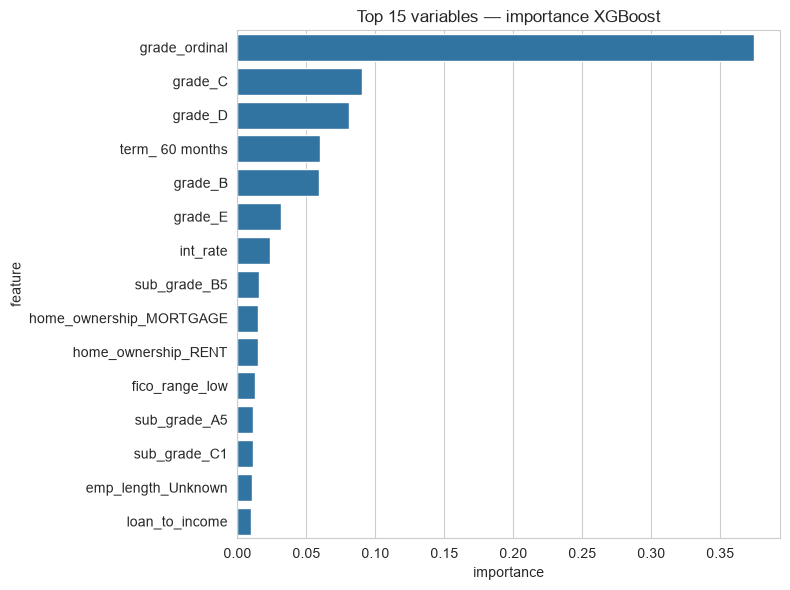

,feature,importance
17,grade_ordinal,0.374549
40,grade_C,0.090521
41,grade_D,0.080572
38,term_ 60 months,0.059972
39,grade_B,0.058948
42,grade_E,0.031849
2,int_rate,0.023821
53,sub_grade_B5,0.015257
31,home_ownership_MORTGAGE,0.014801
35,home_ownership_RENT,0.014521


In [10]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(15), y="feature", x="importance")
plt.title("Top 15 variables — importance XGBoost")
plt.tight_layout()
plt.savefig("../reports/figures/02_feature_importance_xgb.png", dpi=150)
plt.show()

importance.head(15)

## 5. Comparaison des 3 modèles

Trois angles, volontairement complémentaires :
- **AUC-ROC** : capacité globale à discriminer, mais optimiste sous déséquilibre de classes
- **Precision-Recall (AP)** : plus révélatrice ici, avec 20% de défauts seulement
- **Calibration / Brier score** : fiabilité des probabilités prédites, essentielle pour le calcul de perte attendue au notebook 03

### 5.1 Courbes ROC

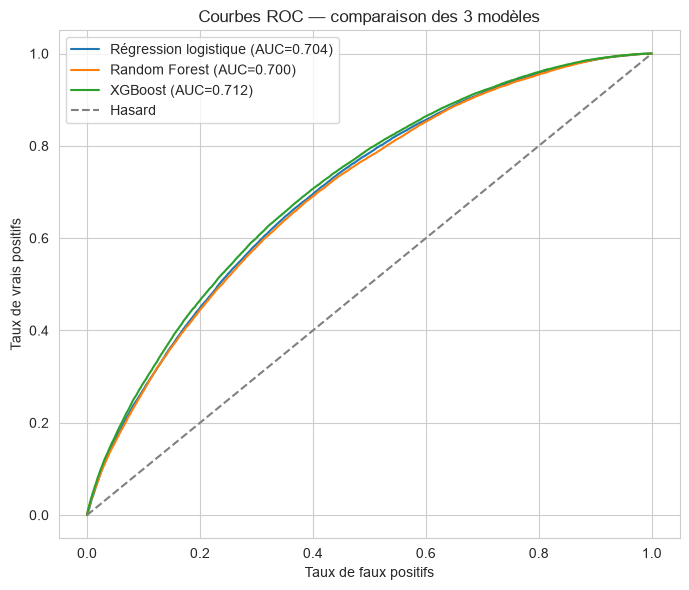

In [11]:
fpr_lr, tpr_lr, _ = compute_roc_curve(y_test, proba_logreg_test)
fpr_rf, tpr_rf, _ = compute_roc_curve(y_test, proba_rf_test)
fpr_xgb, tpr_xgb, _ = compute_roc_curve(y_test, proba_xgb_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Régression logistique (AUC={auc_logreg:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des 3 modèles")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/02_roc_comparison.png", dpi=150)
plt.show()

### 5.2 Courbes Precision-Recall

Plus informatives que l'AUC-ROC sous déséquilibre de classes : la courbe PR se
concentre sur la capacité du modèle à identifier correctement les défauts,
sans être « aidée » par la masse de bons payeurs faciles à classer.

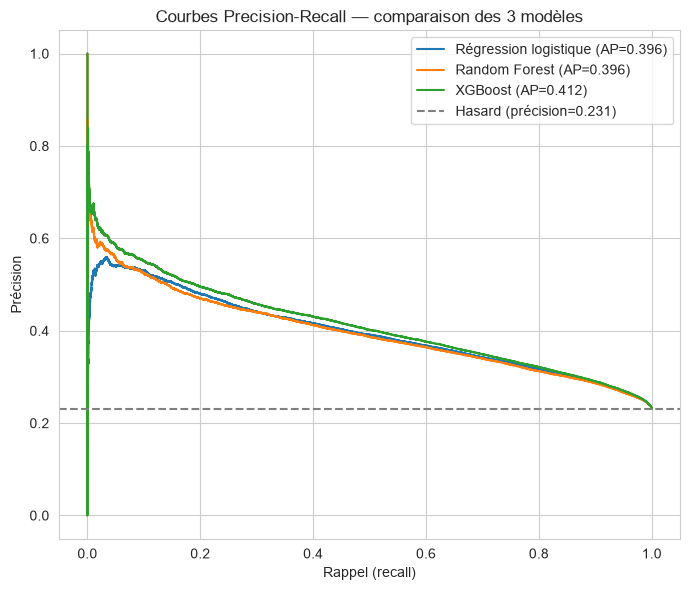

In [12]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, proba_logreg_test)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, proba_rf_test)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, proba_xgb_test)

ap_lr = average_precision_score(y_test, proba_logreg_test)
ap_rf = average_precision_score(y_test, proba_rf_test)
ap_xgb = average_precision_score(y_test, proba_xgb_test)

baseline_precision = y_test.mean()

plt.figure(figsize=(7, 6))
plt.plot(recall_lr, precision_lr, label=f"Régression logistique (AP={ap_lr:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP={ap_rf:.3f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP={ap_xgb:.3f})")
plt.axhline(baseline_precision, linestyle="--", color="gray",
            label=f"Hasard (précision={baseline_precision:.3f})")
plt.xlabel("Rappel (recall)")
plt.ylabel("Précision")
plt.title("Courbes Precision-Recall — comparaison des 3 modèles")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/02_pr_curve_comparison.png", dpi=150)
plt.show()

### 5.3 Calibration

Un modèle bien calibré prédit des probabilités fiables (une prédiction à 20% de
risque doit correspondre, en moyenne, à un taux de défaut observé de 20%) —
condition nécessaire pour que le calcul de perte attendue (EL) au notebook 03
soit crédible.

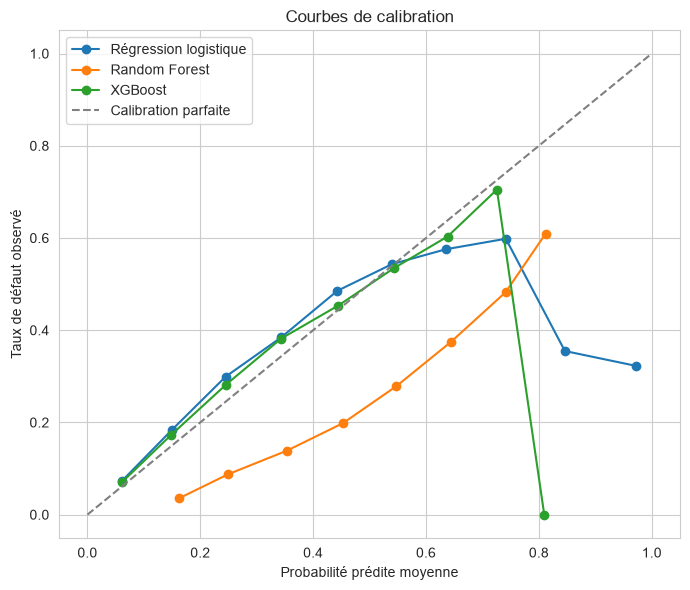

Brier score régression logistique : 0.1633
Brier score Random Forest          : 0.2190
Brier score XGBoost                : 0.1607


In [13]:
prob_true_lr, prob_pred_lr = calibration_curve(y_test, proba_logreg_test, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, proba_rf_test, n_bins=10)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, proba_xgb_test, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Régression logistique")
plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
plt.plot(prob_pred_xgb, prob_true_xgb, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
plt.xlabel("Probabilité prédite moyenne")
plt.ylabel("Taux de défaut observé")
plt.title("Courbes de calibration")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/02_calibration.png", dpi=150)
plt.show()

brier_lr = compute_brier_score(y_test, proba_logreg_test)
brier_rf = compute_brier_score(y_test, proba_rf_test)
brier_xgb = compute_brier_score(y_test, proba_xgb_test)
print(f"Brier score régression logistique : {brier_lr:.4f}")
print(f"Brier score Random Forest          : {brier_rf:.4f}")
print(f"Brier score XGBoost                : {brier_xgb:.4f}")

### 5.4 Tableau de synthèse

In [14]:
summary = pd.DataFrame({
    "Modèle": ["Régression logistique", "Random Forest", "XGBoost"],
    "AUC-ROC": [auc_logreg, auc_rf, auc_xgb],
    "Average Precision (PR-AUC)": [ap_lr, ap_rf, ap_xgb],
    "Brier score": [brier_lr, brier_rf, brier_xgb],
}).set_index("Modèle")

summary

,AUC-ROC,Average Precision (PR-AUC),Brier score
Modèle,,,
Régression logistique,0.704224,0.395904,0.163250
Random Forest,0.700298,0.396141,0.219038
XGBoost,0.712141,0.411749,0.160701


## 6. Choix du modèle final

XGBoost l'emporte sur les trois métriques

In [15]:
final_model_name = "xgb" 

models = {
    "logreg": (logreg, proba_logreg_test),
    "rf": (rf, proba_rf_test),
    "xgb": (xgb, proba_xgb_test),
}
final_model, proba_final_test = models[final_model_name]
print(f"Modèle final retenu : {final_model_name}")

Modèle final retenu : xgb


## 7. Seuil optimal par coût métier

Coût FN (défaut non détecté) : perte moyenne estimée d'un défaut non anticipé.  
Coût FP (bon client refusé) : manque à gagner (marge d'intérêt perdue).

Ratio de départ : un défaut non détecté coûte nettement plus cher qu'un bon  
client refusé - 5:1 à ajuster selon l'analyse métier réelle.

In [16]:
cost_fn = 5.0
cost_fp = 1.0

best_threshold, best_cost = optimal_threshold_by_cost(
    y_test.values, proba_final_test, cost_fn, cost_fp
)
print(f"Seuil optimal (coût métier, {final_model_name}) : {best_threshold:.3f}")
print(f"Coût total au seuil optimal : {best_cost:,.0f}".replace(",", " "))

y_pred_default = (proba_final_test >= 0.5).astype(int)
y_pred_optimal = (proba_final_test >= best_threshold).astype(int)

print("\n--- Seuil 0.5 (référence) ---")
print(confusion_matrix(y_test, y_pred_default))
print("\n--- Seuil optimal (coût métier) ---")
print(confusion_matrix(y_test, y_pred_optimal))

Seuil optimal (coût métier, xgb) : 0.140
Coût total au seuil optimal : 104 809

--- Seuil 0.5 (référence) ---
[[127298   2854]
 [ 35593   3576]]

--- Seuil optimal (coût métier) ---
[[54868 75284]
 [ 5905 33264]]


## 8. Analyse complémentaire : apport de la politique d'octroi Lending Club

`grade`/`sub_grade` sont le score de risque propriétaire de Lending Club,
calculé à l'octroi. `int_rate` en est un quasi-proxy direct (tarification fixée
par sub_grade, écart-type intra-sub_grade très faible). On isole ici ce que les
caractéristiques propres de l'emprunteur (revenu, DTI, historique de crédit)
apportent, indépendamment de toute décision d'octroi du prêteur.

Cette analyse est complémentaire : elle éclaire l'interprétation du modèle,
mais **le modèle final retenu ci-dessus (avec toutes les features) reste celui
utilisé pour la suite du projet** (notebook 03, LGD/EAD/EL), c'est celui
qu'une banque utiliserait réellement en production.

In [17]:
underwriting_cols = [c for c in X_train.columns if c.startswith(("grade", "sub_grade"))] + ["int_rate", "installment"]
underwriting_cols = [c for c in underwriting_cols if c in X_train.columns]
print(f"Colonnes retirées (politique d'octroi) : {underwriting_cols}")

X_train_raw = X_train.drop(columns=underwriting_cols)
X_test_raw = X_test.drop(columns=underwriting_cols)

xgb_raw = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
    random_state=42, n_jobs=-1,
)
xgb_raw.fit(X_train_raw, y_train)
proba_raw = xgb_raw.predict_proba(X_test_raw)[:, 1]

auc_raw = compute_auc(y_test, proba_raw)
print(f"\nAUC-ROC XGBoost — caractéristiques emprunteur uniquement : {auc_raw:.4f}")
print(f"AUC-ROC XGBoost — avec grade/sub_grade/int_rate          : {auc_xgb:.4f}")
print(f"Écart attribuable à la politique d'octroi Lending Club    : {auc_xgb - auc_raw:.4f}")

Colonnes retirées (politique d'octroi) : ['grade_ordinal', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'int_rate', 'installment']

AUC-ROC XGBoost — caractéristiques emprunteur uniquement : 0.6998
AUC-ROC XGBoost — avec grade/sub_grade/int_rate          : 0.7121
Écart attribuable à la politique d'octroi Lending Club    : 0.0124


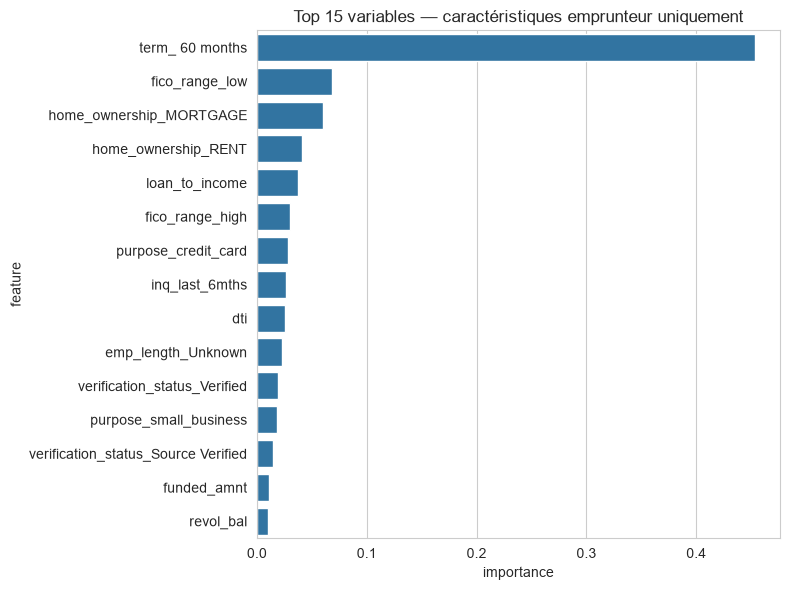

,feature,importance
35,term_ 60 months,0.453536
4,fico_range_low,0.068240
28,home_ownership_MORTGAGE,0.059958
32,home_ownership_RENT,0.040856
14,loan_to_income,0.037412
5,fico_range_high,0.030368
15,purpose_credit_card,0.028657
11,inq_last_6mths,0.026738
3,dti,0.025857
46,emp_length_Unknown,0.022990


In [18]:
importance_raw = pd.DataFrame({
    "feature": X_train_raw.columns,
    "importance": xgb_raw.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_raw.head(15), y="feature", x="importance")
plt.title("Top 15 variables — caractéristiques emprunteur uniquement")
plt.tight_layout()
plt.savefig("../reports/figures/02_feature_importance_raw.png", dpi=150)
plt.show()

importance_raw.head(15)

## 9. Sauvegarde du modèle final et des prédictions

Sauvegarde du modèle retenu (section 6) et des probabilités prédites,
réutilisées au notebook 03 pour le calcul de la perte attendue.

In [22]:
# Sauvegarde des colonnes et valeurs de référence, nécessaires pour reconstruire
# un vecteur de features cohérent depuis l'app Streamlit (un nouveau prêt saisi
# à la main n'aura pas toutes les colonnes one-hot déjà présentes)
joblib.dump(list(X_train.columns), "../reports/feature_columns_pd.pkl")
joblib.dump(X_train.median(numeric_only=True), "../reports/feature_medians_pd.pkl")

['../reports/feature_medians_pd.pkl']

In [19]:
joblib.dump(final_model, f"../reports/model_pd_{final_model_name}.pkl")
joblib.dump(scaler, "../reports/scaler_logreg.pkl")

test_with_proba = test.copy()
test_with_proba["pd_pred"] = proba_final_test
test_with_proba.to_parquet("../data/processed/test_with_pd.parquet", index=False)

print("Modèle et prédictions sauvegardés.")
print(f"\nModèle final : {final_model_name}")
print(f"Seuil optimal retenu : {best_threshold:.3f}")
print(f"AUC-ROC final : {compute_auc(y_test, proba_final_test):.4f}")

Modèle et prédictions sauvegardés.

Modèle final : xgb
Seuil optimal retenu : 0.140
AUC-ROC final : 0.7121


## 10. Validation temporelle (walk-forward)

Le split unique train (≤2016) / test (2017) ne dit rien sur la stabilité du
modèle dans le temps. On simule ici un entraînement glissant : à chaque
étape, on entraîne sur toutes les années disponibles jusqu'à une année N, et
on teste sur l'année N+1 — reproduisant la façon dont un modèle serait
réévalué chaque année en production.

In [20]:
df_full = pd.read_parquet("../data/processed/accepted_filtered_2007_2017.parquet")
df_full["issue_d"] = pd.to_datetime(df_full["issue_d"])

def prepare_fold(df_source, train_years, test_year):
    """Reproduit exactement la pipeline de préparation (winsorisation, encodage,
    nettoyage des noms) pour un découpage temporel donné."""
    train_f = df_source[df_source["issue_d"].dt.year.isin(train_years)].copy()
    test_f = df_source[df_source["issue_d"].dt.year == test_year].copy()

    from src.features import build_features
    from src.data_prep import select_features
    train_f = select_features(train_f)
    test_f = select_features(test_f)
    train_f["issue_d"] = df_source.loc[train_f.index, "issue_d"]
    train_f["earliest_cr_line"] = df_source.loc[train_f.index, "earliest_cr_line"]
    test_f["issue_d"] = df_source.loc[test_f.index, "issue_d"]
    test_f["earliest_cr_line"] = df_source.loc[test_f.index, "earliest_cr_line"]
    train_f = build_features(train_f)
    test_f = build_features(test_f)

    cap = train_f["loan_to_income"].quantile(0.99)
    train_f["loan_to_income"] = train_f["loan_to_income"].clip(upper=cap).fillna(train_f["loan_to_income"].median())
    test_f["loan_to_income"] = test_f["loan_to_income"].clip(upper=cap).fillna(train_f["loan_to_income"].median())

    cat_cols = train_f.select_dtypes(include=["object", "category"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c != "loan_status"]
    tr = pd.get_dummies(train_f.drop(columns=["loan_status"]), columns=cat_cols, drop_first=True)
    te = pd.get_dummies(test_f.drop(columns=["loan_status"]), columns=cat_cols, drop_first=True)
    tr, te = tr.align(te, join="left", axis=1, fill_value=0)

    drop_c = ["default", "issue_d", "earliest_cr_line"]
    Xtr, ytr = clean_feature_names(tr.drop(columns=drop_c)), tr["default"]
    Xte, yte = clean_feature_names(te.drop(columns=drop_c)), te["default"]
    Xtr = Xtr.fillna(Xtr.median(numeric_only=True))
    Xte = Xte.fillna(Xtr.median(numeric_only=True))
    return Xtr, ytr, Xte, yte

folds = [
    (list(range(2007, 2014)), 2014),
    (list(range(2007, 2015)), 2015),
    (list(range(2007, 2016)), 2016),
    (list(range(2007, 2017)), 2017),
]

wf_results = []
for train_years, test_year in folds:
    Xtr, ytr, Xte, yte = prepare_fold(df_full, train_years, test_year)
    model_fold = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
        random_state=42, n_jobs=-1,
    )
    model_fold.fit(Xtr, ytr)
    proba_fold = model_fold.predict_proba(Xte)[:, 1]
    auc_fold = compute_auc(yte, proba_fold)
    wf_results.append({"train_jusqu_a": max(train_years), "test_annee": test_year,
                        "n_train": len(ytr), "n_test": len(yte), "auc": auc_fold,
                        "taux_defaut_test": yte.mean()})
    print(f"Train ≤{max(train_years)} → Test {test_year} : AUC = {auc_fold:.4f}, "
          f"taux défaut test = {yte.mean():.2%}")

wf_df = pd.DataFrame(wf_results)
wf_df

C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8456\683177672.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly

Train ≤2013 → Test 2014 : AUC = 0.7088, taux défaut test = 18.45%


C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8456\683177672.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly

Train ≤2014 → Test 2015 : AUC = 0.7331, taux défaut test = 20.19%


C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8456\683177672.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly

Train ≤2015 → Test 2016 : AUC = 0.7140, taux défaut test = 23.29%


C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\Documents\Projets_personnels\03-credit-risk-scoring\notebooks\..\src\features.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8456\683177672.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly

Train ≤2016 → Test 2017 : AUC = 0.7104, taux défaut test = 23.13%


,train_jusqu_a,test_annee,n_train,n_test,auc,taux_defaut_test
0,2013,2014,227957,223103,0.708797,0.184498
1,2014,2015,451060,375546,0.733126,0.201850
2,2015,2016,826606,293105,0.714023,0.232859
3,2016,2017,1119711,169321,0.710437,0.231330


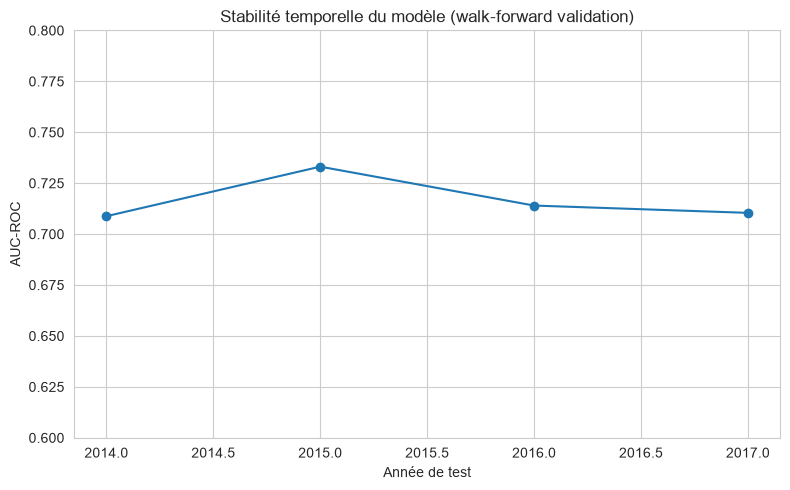

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(wf_df["test_annee"], wf_df["auc"], marker="o")
plt.xlabel("Année de test")
plt.ylabel("AUC-ROC")
plt.title("Stabilité temporelle du modèle (walk-forward validation)")
plt.ylim(0.6, 0.8)
plt.tight_layout()
plt.savefig("../reports/figures/02_walk_forward_auc.png", dpi=150)
plt.show()

wf_df.to_csv("../reports/walk_forward_results.csv", index=False)

## 11. Synthèse des résultats clés

### 11.1 Modèle retenu

Après comparaison de la régression logistique, du Random Forest et de XGBoost, **XGBoost a été retenu comme modèle final**.

Il obtient les meilleures performances globales :

| Modèle                |    AUC-ROC | Average Precision | Brier Score |
| --------------------- | ---------: | ----------------: | ----------: |
| Régression logistique |     0,7042 |            0,3959 |      0,1633 |
| Random Forest         |     0,7003 |            0,3961 |      0,2190 |
| **XGBoost**           | **0,7121** |        **0,4118** |  **0,1607** |

XGBoost présente ainsi le meilleur compromis entre **capacité de discrimination**, **détection de la classe minoritaire** et **fiabilité des probabilités prédites**.

### 11.2 Optimisation du seuil de décision

Le seuil conventionnel de **0,5** s'est révélé trop conservateur : seuls **3 576 défauts sur 39 169** ont été détectés, soit un rappel d'environ **9 %**.

En intégrant le coût métier des erreurs, avec un rapport **FN:FP = 5:1**, le seuil optimal a été fixé à **0,140**.

À ce seuil :

* **33 264 défauts** sont correctement détectés ;
* le rappel atteint environ **85 %** ;
* **75 284 faux positifs** sont générés.

Ce résultat illustre clairement le compromis entre le coût d'un **défaut non détecté** et celui d'un **bon client incorrectement classé comme risqué**.

### 11.3 Variables les plus prédictives

La variable `grade_ordinal` constitue la principale variable prédictive du modèle, avec une importance de **37,5 %**.

Elle est suivie notamment par :

1. `grade_C`
2. `grade_D`
3. `term_60 months`
4. `grade_B`
5. `grade_E`
6. `int_rate`

Ces résultats montrent que la **politique de scoring et de tarification de Lending Club** contient une part importante du signal permettant de prédire le défaut.

### 11.4 Analyse de l'influence de la politique de Lending Club

Une analyse complémentaire a été réalisée en retirant les variables `grade`, `sub_grade` et `int_rate`.

| Configuration                        |      AUC-ROC |
| ------------------------------------ | -----------: |
| Sans variables de politique d'octroi |   **0,6998** |
| Avec politique d'octroi complète     |   **0,7121** |
| Gain d'AUC                           | **≈ 0,0124** |

L'écart reste relativement limité. Cela signifie que les caractéristiques propres à l'emprunteur conservent une **capacité prédictive importante**, même en l'absence des variables issues directement de la politique de crédit de Lending Club.

Ainsi, un modèle de scoring indépendant du prêteur demeure envisageable.

### 11.5 Conclusion générale

Les résultats montrent qu'un modèle de Machine Learning peut fournir une **probabilité de défaut exploitable pour l'aide à la décision en matière de risque de crédit**.

La démarche ne se limite toutefois pas au choix du meilleur algorithme. Elle intègre également :

**Données → Modélisation → Probabilité de défaut → Optimisation du seuil → Décision métier**

Le modèle **XGBoost**, associé à un seuil de décision de **0,140**, constitue ainsi la solution retenue pour la suite de l'analyse, notamment pour le calcul de la **perte attendue (Expected Loss)**.

###  À retenir

> **XGBoost a été retenu avec une AUC de 0,7121, une Average Precision de 0,4118 et un Brier score de 0,1607. Le seuil de 0,5 étant trop conservateur, un seuil de 0,140 a été déterminé en tenant compte du coût métier des erreurs, permettant d'atteindre environ 85 % de rappel. Enfin, l'analyse montre que les variables de l'emprunteur conservent une capacité prédictive proche de 0,70 d'AUC même sans les variables de scoring propriétaires de Lending Club.**
